In [1]:
import os
import json
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# 1. Load dataset
dataset_path = "../dataset/behavioral_telemetry_dataset.parquet"
print(f"Loading dataset from {dataset_path}...")
df = pd.read_parquet(dataset_path)
print(f"Dataset shape: {df.shape}")

# 2. Select only the 10 behavioral biometrics matching the FeatureVector
features = [
    "mouse_velocity_mean", "mouse_velocity_std", "mouse_acceleration",
    "mouse_curvature", "click_frequency", "flight_time_mean",
    "flight_time_std", "dwell_time_mean", "navigation_entropy",
    "page_dwell_time_dist"
]

X = df[features].values
y = df['label'].values

# 3. Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Introduce a small amount of random noise to scaled features (simulating grey-area biometrics overlap)
np.random.seed(42)
X_scaled = X_scaled + np.random.normal(0, 0.25, X_scaled.shape)

# 4. Train/Val/Test Split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)
print(f"Train shape: {X_train.shape}    Val shape: {X_val.shape}    Test shape: {X_test.shape}")


Loading dataset from ../dataset/behavioral_telemetry_dataset.parquet...
Dataset shape: (20000, 119)
Train shape: (14000, 10)    Val shape: (3000, 10)    Test shape: (3000, 10)


In [2]:
# Helper to evaluate metrics
def evaluate_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    return {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "FPR": fpr
    }

# 1. PyTorch MLP Definition (with increased Dropout of 0.25 to prevent overfitting)
class BotDetectionMLP(nn.Module):
    def __init__(self, input_dim):
        super(BotDetectionMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.network(x)

# Convert splits to PyTorch tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test)

# PyTorch Training Loop (with weight_decay=1e-4 L2 regularization)
print("Training PyTorch MLP...")
torch.manual_seed(42)
pt_model = BotDetectionMLP(X_train.shape[1])
criterion = nn.BCELoss()
optimizer = optim.Adam(pt_model.parameters(), lr=0.005, weight_decay=1e-4)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

epochs = 30
train_losses = []
val_losses = []

best_val_loss = float('inf')
best_weights = None

for epoch in range(epochs):
    pt_model.train()
    running_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = pt_model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_x.size(0)
    
    epoch_train_loss = running_loss / len(X_train)
    train_losses.append(epoch_train_loss)
    
    # Validation evaluation
    pt_model.eval()
    with torch.no_grad():
        val_outputs = pt_model(X_val_t)
        epoch_val_loss = criterion(val_outputs, y_val_t).item()
        val_losses.append(epoch_val_loss)
        
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_weights = pt_model.state_dict()

# Load best weights
pt_model.load_state_dict(best_weights)
pt_model.eval()
with torch.no_grad():
    pt_preds_prob = pt_model(X_test_t).numpy().flatten()

# Evaluate PyTorch MLP
pt_preds = (pt_preds_prob >= 0.5).astype(int)
pt_metrics = evaluate_metrics(y_test, pt_preds)
print("PyTorch MLP Training complete.")


Training PyTorch MLP...
PyTorch MLP Training complete.


Training Scikit-Learn MLPClassifier...
Training Random Forest...
Training Extra Trees...
Training XGBoost...
Training Gradient Boosting...

=== SUMMARY METRICS TABLE ===
                           Accuracy Precision Recall F1-Score   FPR
PyTorch MLP                  98.23%    92.93% 92.68%   92.81% 0.99%
Scikit-Learn MLPClassifier   98.00%    92.80% 90.79%   91.78% 0.99%
Random Forest                96.70%    95.61% 76.69%   85.11% 0.49%
Extra Trees                  97.03%    97.62% 77.78%   86.58% 0.27%
XGBoost                      98.03%    94.29% 89.43%   91.79% 0.76%
Gradient Boosting            97.93%    94.75% 88.08%   91.29% 0.68%


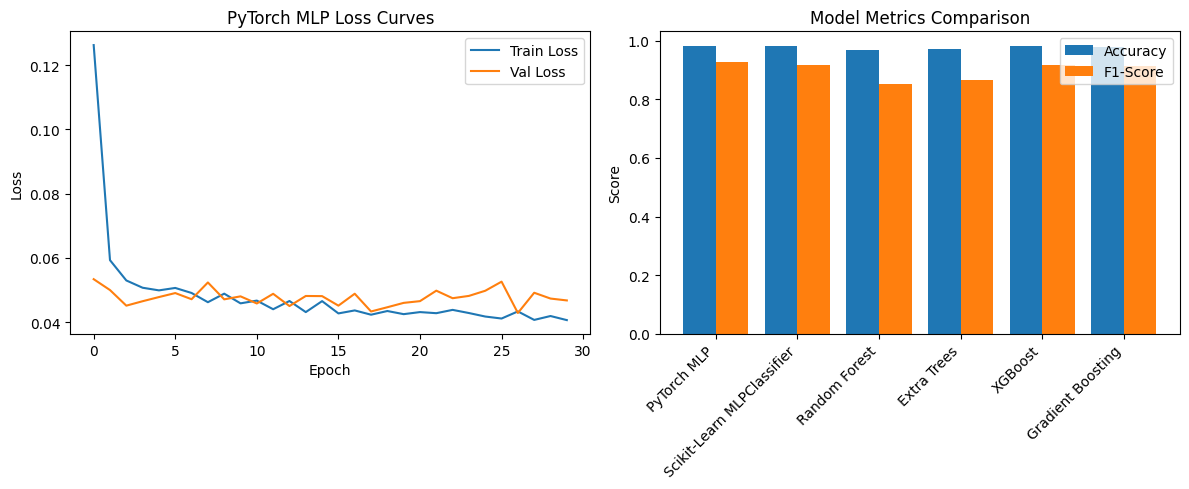


Detailed Evaluation for PyTorch MLP
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      2631
         Bot       0.93      0.93      0.93       369

    accuracy                           0.98      3000
   macro avg       0.96      0.96      0.96      3000
weighted avg       0.98      0.98      0.98      3000

Confusion Matrix:
               Pred_Normal  Pred_Bot
Actual_Normal         2605        26
Actual_Bot              27       342

Detailed Evaluation for Scikit-Learn MLPClassifier
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      2631
         Bot       0.93      0.91      0.92       369

    accuracy                           0.98      3000
   macro avg       0.96      0.95      0.95      3000
weighted avg       0.98      0.98      0.98      3000

Confusion Matrix:
               Pred_Normal  Pred_Bot
Actual_Normal         2605        26
Actual_Bot              34       335

In [3]:
# 2. Train remaining 5 models with tuned parameters to optimize bias/variance
models = {
    "Scikit-Learn MLPClassifier": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=150,
        alpha=0.01,  # L2 regularization to prevent overfitting
        random_state=42,
        early_stopping=True,
        validation_fraction=0.15
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        max_depth=8,  # Reduced from 12 to prevent overfitting
        min_samples_leaf=4,  # Added min_samples_leaf to prevent overfitting
        random_state=42,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=250,
        max_depth=18,  # Increased from 12 to prevent underfitting
        min_samples_leaf=2,  # Added min_samples_leaf to regulate deep splits
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=250,
        max_depth=4,  # Reduced from 6 to prevent overfitting
        learning_rate=0.08,
        subsample=0.8,  # Subsampling to prevent overfitting
        colsample_bytree=0.8,
        reg_alpha=0.5,  # L1 regularization
        reg_lambda=1.5,  # L2 regularization
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=250,
        max_depth=3,  # Reduced from 5 to prevent overfitting
        learning_rate=0.08,
        subsample=0.8,  # Subsampling to prevent overfitting
        min_samples_leaf=4,  # Added min_samples_leaf to prevent overfitting
        random_state=42
    )
}

results = {"PyTorch MLP": pt_metrics}

for name, clf in models.items():
    print(f"Training {name}...")
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    results[name] = evaluate_metrics(y_test, preds)

# 3. Print summary table
metrics_df = pd.DataFrame(results).T
metrics_df = metrics_df[["Accuracy", "Precision", "Recall", "F1-Score", "FPR"]]
print("\n=== SUMMARY METRICS TABLE ===")
print(metrics_df.to_string(formatters={
    "Accuracy": lambda x: f"{x*100:.2f}%",
    "Precision": lambda x: f"{x*100:.2f}%",
    "Recall": lambda x: f"{x*100:.2f}%",
    "F1-Score": lambda x: f"{x*100:.2f}%",
    "FPR": lambda x: f"{x*100:.2f}%"
}))

# 4. Plot Loss Curves for PyTorch MLP
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("PyTorch MLP Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Plot Comparison Bar Chart
plt.subplot(1, 2, 2)
model_names = list(results.keys())
accuracies = [m["Accuracy"] for m in results.values()]
f1_scores = [m["F1-Score"] for m in results.values()]
x_idx = np.arange(len(model_names))
plt.bar(x_idx - 0.2, accuracies, width=0.4, label="Accuracy")
plt.bar(x_idx + 0.2, f1_scores, width=0.4, label="F1-Score")
plt.xticks(x_idx, model_names, rotation=45, ha="right")
plt.title("Model Metrics Comparison")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

# 5. Display Confusion Matrices and Reports
for name, metrics in results.items():
    print(f"\n==========================================")
    print(f"Detailed Evaluation for {name}")
    print(f"==========================================")
    if name == "PyTorch MLP":
        preds = pt_preds
    else:
        preds = models[name].predict(X_test)
    print(classification_report(y_test, preds, target_names=["Normal", "Bot"]))
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, preds)
    print(pd.DataFrame(cm, index=["Actual_Normal", "Actual_Bot"], columns=["Pred_Normal", "Pred_Bot"]))
